# Text Preprocessing

## 0. Dataset Creation

In [1]:
import pandas as pd

data = [
    "When life gives you lemons, make lemonade! 🙂",
    "She bought 2 lemons for $1 at Maven Market.",
    "A dozen lemons will make a gallon of lemonade. [AllRecipes]",
    "lemon, lemon, lemons, lemon, lemon, lemons",
    "He's running to the market to get a lemon — there's a great sale today.",
    "Does Maven Market carry Eureka lemons or Meyer lemons?",
    "An Arnold Palmer is half lemonade, half iced tea. [Wikipedia]",
    "iced tea is my favorite"
]

pd.set_option('display.max_colwidth', None)
data_df = pd.DataFrame(data, columns=['sentence'])

data_df

,sentence
0,"When life gives you lemons, make lemonade! 🙂"
1,She bought 2 lemons for $1 at Maven Market.
2,A dozen lemons will make a gallon of lemonade. [AllRecipes]
3,"lemon, lemon, lemons, lemon, lemon, lemons"
4,He's running to the market to get a lemon — there's a great sale today.
5,Does Maven Market carry Eureka lemons or Meyer lemons?
6,"An Arnold Palmer is half lemonade, half iced tea. [Wikipedia]"
7,iced tea is my favorite


In [2]:
test = [
    "We're going to start this course with traditional NLP applications.",
    "Then we'll move on to modern NLP theory.",
    "Finally, we'll wrap things up with modern NLP applications."
]

test_series = pd.Series(test)
test_series

0    We're going to start this course with traditional NLP applications.
1                               Then we'll move on to modern NLP theory.
2            Finally, we'll wrap things up with modern NLP applications.
dtype: object

**1. Text Preprocessing with Pandas**

In [3]:
df = data_df.copy()
df

,sentence
0,"When life gives you lemons, make lemonade! 🙂"
1,She bought 2 lemons for $1 at Maven Market.
2,A dozen lemons will make a gallon of lemonade. [AllRecipes]
3,"lemon, lemon, lemons, lemon, lemon, lemons"
4,He's running to the market to get a lemon — there's a great sale today.
5,Does Maven Market carry Eureka lemons or Meyer lemons?
6,"An Arnold Palmer is half lemonade, half iced tea. [Wikipedia]"
7,iced tea is my favorite


In [4]:
df['sentence_clean'] = df ['sentence'].str.lower()
df

,sentence,sentence_clean
0,"When life gives you lemons, make lemonade! 🙂","when life gives you lemons, make lemonade! 🙂"
1,She bought 2 lemons for $1 at Maven Market.,she bought 2 lemons for $1 at maven market.
2,A dozen lemons will make a gallon of lemonade. [AllRecipes],a dozen lemons will make a gallon of lemonade. [allrecipes]
3,"lemon, lemon, lemons, lemon, lemon, lemons","lemon, lemon, lemons, lemon, lemon, lemons"
4,He's running to the market to get a lemon — there's a great sale today.,he's running to the market to get a lemon — there's a great sale today.
5,Does Maven Market carry Eureka lemons or Meyer lemons?,does maven market carry eureka lemons or meyer lemons?
6,"An Arnold Palmer is half lemonade, half iced tea. [Wikipedia]","an arnold palmer is half lemonade, half iced tea. [wikipedia]"
7,iced tea is my favorite,iced tea is my favorite


In [5]:
df['sentence_clean'] = df['sentence'].str.replace(r'\[.*?\]', '', regex=True)
df

,sentence,sentence_clean
0,"When life gives you lemons, make lemonade! 🙂","When life gives you lemons, make lemonade! 🙂"
1,She bought 2 lemons for $1 at Maven Market.,She bought 2 lemons for $1 at Maven Market.
2,A dozen lemons will make a gallon of lemonade. [AllRecipes],A dozen lemons will make a gallon of lemonade.
3,"lemon, lemon, lemons, lemon, lemon, lemons","lemon, lemon, lemons, lemon, lemon, lemons"
4,He's running to the market to get a lemon — there's a great sale today.,He's running to the market to get a lemon — there's a great sale today.
5,Does Maven Market carry Eureka lemons or Meyer lemons?,Does Maven Market carry Eureka lemons or Meyer lemons?
6,"An Arnold Palmer is half lemonade, half iced tea. [Wikipedia]","An Arnold Palmer is half lemonade, half iced tea."
7,iced tea is my favorite,iced tea is my favorite


In [6]:
df['sentence_clean'] = df['sentence_clean'].str.replace(r'[^\w\s]', '', regex=True)
df

,sentence,sentence_clean
0,"When life gives you lemons, make lemonade! 🙂",When life gives you lemons make lemonade
1,She bought 2 lemons for $1 at Maven Market.,She bought 2 lemons for 1 at Maven Market
2,A dozen lemons will make a gallon of lemonade. [AllRecipes],A dozen lemons will make a gallon of lemonade
3,"lemon, lemon, lemons, lemon, lemon, lemons",lemon lemon lemons lemon lemon lemons
4,He's running to the market to get a lemon — there's a great sale today.,Hes running to the market to get a lemon theres a great sale today
5,Does Maven Market carry Eureka lemons or Meyer lemons?,Does Maven Market carry Eureka lemons or Meyer lemons
6,"An Arnold Palmer is half lemonade, half iced tea. [Wikipedia]",An Arnold Palmer is half lemonade half iced tea
7,iced tea is my favorite,iced tea is my favorite


**Create a Lower_replace function**

In [7]:
def lower_replace (series):
    output = series.str.lower()
    output = output.str.replace(r'\[.*?\]', '', regex=True)
    output = output.str.replace(r'[^\w\s]', '', regex=True)
    return output

In [8]:
lower_replace(test_series)

0    were going to start this course with traditional nlp applications
1                               then well move on to modern nlp theory
2             finally well wrap things up with modern nlp applications
dtype: object

In [9]:
lower_replace(df.sentence)

0                              when life gives you lemons make lemonade 
1                              she bought 2 lemons for 1 at maven market
2                         a dozen lemons will make a gallon of lemonade 
3                                  lemon lemon lemons lemon lemon lemons
4    hes running to the market to get a lemon  theres a great sale today
5                  does maven market carry eureka lemons or meyer lemons
6                       an arnold palmer is half lemonade half iced tea 
7                                                iced tea is my favorite
Name: sentence, dtype: object

In [10]:
import spacy
nlp = spacy.load('en_core_web_sm')

In [11]:
phrase = df.sentence_clean[0]
phrase

'When life gives you lemons make lemonade '

In [12]:
doc = nlp(phrase)
doc

When life gives you lemons make lemonade 

In [13]:
[token.lemma_ for token in doc]

['when', 'life', 'give', 'you', 'lemon', 'make', 'lemonade']

In [14]:
norm = [token.lemma_ for token in doc if not token.is_stop]
norm

['life', 'give', 'lemon', 'lemonade']

In [15]:
list(nlp.Defaults.stop_words)[:10]

['anyone',
 'what',
 'hereafter',
 'take',
 'thru',
 'whether',
 'them',
 'besides',
 'will',
 'eleven']

In [16]:
' '.join(norm)

'life give lemon lemonade'

## 1. Create a token_lemma_nonstop()

In [17]:
def token_lemma_nonstop(text):
    doc = nlp(text)
    output = [token.lemma_ for token in doc if not token.is_stop]
    output = ' '.join(output)
    return output

In [18]:
test_series

0    We're going to start this course with traditional NLP applications.
1                               Then we'll move on to modern NLP theory.
2            Finally, we'll wrap things up with modern NLP applications.
dtype: object

In [19]:
test_series.apply(token_lemma_nonstop)

0    go start course traditional NLP application .
1                              modern NLP theory .
2    finally , wrap thing modern NLP application .
dtype: object

In [20]:
df.sentence_clean

0                              When life gives you lemons make lemonade 
1                              She bought 2 lemons for 1 at Maven Market
2                         A dozen lemons will make a gallon of lemonade 
3                                  lemon lemon lemons lemon lemon lemons
4    Hes running to the market to get a lemon  theres a great sale today
5                  Does Maven Market carry Eureka lemons or Meyer lemons
6                       An Arnold Palmer is half lemonade half iced tea 
7                                                iced tea is my favorite
Name: sentence_clean, dtype: object

In [21]:
lower_replace(df.sentence_clean).apply(token_lemma_nonstop)

0                       life give lemon lemonade
1                     buy 2 lemon 1 maven market
2                    dozen lemon gallon lemonade
3            lemon lemon lemon lemon lemon lemon
4        s run market lemon   s great sale today
5    maven market carry eureka lemon meyer lemon
6       arnold palmer half lemonade half ice tea
7                               ice tea favorite
Name: sentence_clean, dtype: object

## 2. POS Tagging

In [22]:
phrase2 = lower_replace(df.sentence_clean).apply(token_lemma_nonstop) [0]
phrase2

'life give lemon lemonade'

In [23]:
doc2 = nlp(phrase2)
doc2

life give lemon lemonade

In [24]:
pos = [(token.text, token.pos_) for token in doc2]
pos

[('life', 'NOUN'), ('give', 'VERB'), ('lemon', 'NOUN'), ('lemonade', 'PROPN')]

In [25]:
nouns = [(token.text) for token in doc2 if token.pos_ in ['NOUN', "PROPN"]]
nouns

['life', 'lemon', 'lemonade']

In [26]:
' '.join(nouns)

'life lemon lemonade'

## 3. Create a filter_pos function

In [27]:
def filter_pos(text, pos_list = ['NOUN', 'PROPN']):
    doc = nlp(text)
    output = [(token.text) for token in doc if token.pos_ in pos_list]
    output = ' '.join(output)
    return output

In [28]:
test_series.apply(filter_pos)

0    course NLP applications
1                 NLP theory
2    things NLP applications
dtype: object

In [29]:
lower_replace(df.sentence).apply(token_lemma_nonstop).apply(filter_pos)

0                    life lemon lemonade
1                     lemon maven market
2            dozen lemon gallon lemonade
3    lemon lemon lemon lemon lemon lemon
4              s market lemon sale today
5        maven market eureka lemon lemon
6           palmer lemonade half ice tea
7                       ice tea favorite
Name: sentence, dtype: object

# Create a Custom NLP Pipeline

In [30]:
def nlp_pipeline(series):
    output = lower_replace(series)
    output = output.apply(token_lemma_nonstop)
    output = output.apply(filter_pos)
    return output

In [31]:
test_series

0    We're going to start this course with traditional NLP applications.
1                               Then we'll move on to modern NLP theory.
2            Finally, we'll wrap things up with modern NLP applications.
dtype: object

In [32]:
nlp_pipeline(test_series)

0          nlp application
1               nlp theory
2    thing nlp application
dtype: object

In [33]:
df.sentence

0                               When life gives you lemons, make lemonade! 🙂
1                                She bought 2 lemons for $1 at Maven Market.
2                A dozen lemons will make a gallon of lemonade. [AllRecipes]
3                                 lemon, lemon, lemons, lemon, lemon, lemons
4    He's running to the market to get a lemon — there's a great sale today.
5                     Does Maven Market carry Eureka lemons or Meyer lemons?
6              An Arnold Palmer is half lemonade, half iced tea. [Wikipedia]
7                                                    iced tea is my favorite
Name: sentence, dtype: object

In [34]:
text_clean = nlp_pipeline(df.sentence)
text_clean

0                    life lemon lemonade
1                     lemon maven market
2            dozen lemon gallon lemonade
3    lemon lemon lemon lemon lemon lemon
4              s market lemon sale today
5        maven market eureka lemon lemon
6           palmer lemonade half ice tea
7                       ice tea favorite
Name: sentence, dtype: object

In [35]:
pd.to_pickle(text_clean, 'text_clean.pkl')

## 4. Count Vectorizer

In [36]:
series = pd.read_pickle('text_clean.pkl')
series

0                    life lemon lemonade
1                     lemon maven market
2            dozen lemon gallon lemonade
3    lemon lemon lemon lemon lemon lemon
4              s market lemon sale today
5        maven market eureka lemon lemon
6           palmer lemonade half ice tea
7                       ice tea favorite
Name: sentence, dtype: object

In [37]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()
dtm = cv.fit_transform(series)
dtm_df = pd.DataFrame(dtm.toarray(), columns = cv.get_feature_names_out())
dtm_df

,dozen,eureka,favorite,gallon,half,ice,lemon,lemonade,life,market,maven,palmer,sale,tea,today
0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0
2,1,0,0,1,0,0,1,1,0,0,0,0,0,0,0
3,0,0,0,0,0,0,6,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0,1,0,0,1,0,1
5,0,1,0,0,0,0,2,0,0,1,1,0,0,0,0
6,0,0,0,0,1,1,0,1,0,0,0,1,0,1,0
7,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0


In [38]:
cv2 = CountVectorizer(stop_words='english', ngram_range=(1, 2), min_df=2, max_df=.8)
cv2

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,stop_words,'english'
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"
,analyzer,'word'


In [39]:
dtm2 = cv2.fit_transform(series)
dtm_df2 = pd.DataFrame(dtm2.toarray(), columns=cv2.get_feature_names_out())
dtm_df2

,ice,ice tea,lemon,lemon lemon,lemonade,market,maven,maven market,tea
0,0,0,1,0,1,0,0,0,0
1,0,0,1,0,0,1,1,1,0
2,0,0,1,0,1,0,0,0,0
3,0,0,6,5,0,0,0,0,0
4,0,0,1,0,0,1,0,0,0
5,0,0,2,1,0,1,1,1,0
6,1,1,0,0,1,0,0,0,1
7,1,1,0,0,0,0,0,0,1


## EDA with Count Vectorizer

In [40]:
term_freq = dtm_df2.sum()
term_freq

ice              2
ice tea          2
lemon           12
lemon lemon      6
lemonade         3
market           3
maven            2
maven market     2
tea              2
dtype: int64

<Axes: >

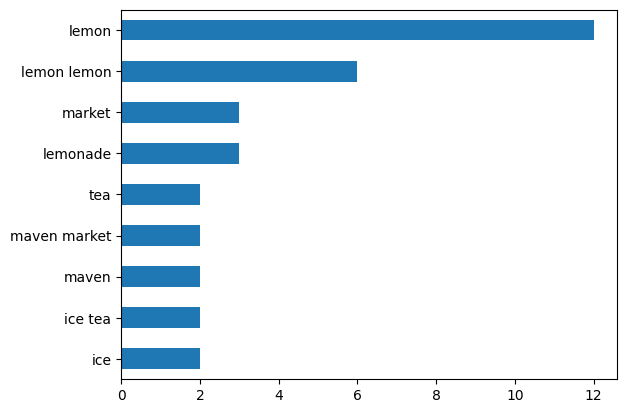

In [41]:
term_freq.sort_values().plot(kind='barh')

## 5. TF-IDF Vectorizer

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer

tv = TfidfVectorizer()
tfidf = tv.fit_transform(series)
tfidf_df = pd.DataFrame(tfidf.toarray(), columns=tv.get_feature_names_out())
tfidf_df

,dozen,eureka,favorite,gallon,half,ice,lemon,lemonade,life,market,maven,palmer,sale,tea,today
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.375318,0.543168,0.75107,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.411442,0.000000,0.00000,0.595449,0.690041,0.000000,0.000000,0.000000,0.000000
2,0.600547,0.000000,0.000000,0.600547,0.000000,0.000000,0.300100,0.434311,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.300100,0.000000,0.00000,0.434311,0.000000,0.000000,0.600547,0.000000,0.600547
5,0.000000,0.556913,0.000000,0.000000,0.000000,0.000000,0.556591,0.000000,0.00000,0.402755,0.466736,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.504577,0.422875,0.000000,0.364907,0.00000,0.000000,0.000000,0.504577,0.000000,0.422875,0.000000
7,0.000000,0.000000,0.644859,0.000000,0.000000,0.540443,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.540443,0.000000
